In [2]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import gstools as gs
import pymc as pm
import statsmodels.api as sm
import arviz as az
import pytensor.tensor as pt
import pickle
import pathlib
from scipy.spatial.distance import cdist

In [3]:
contrib = pd.read_csv("../data/senate_campaign_data_by_zip.csv")
contrib.head()

,YEAR,ZIP_CODE,STATE,CAND_OFFICE_ST,CAND_PTY_AFFILIATION,TRANSACTION_AMT,population,median_income,educ_attainment_pop_18plus,college_degree_or_higher_count_18plus,prop_college_degree_or_higher_18plus,high_school_or_higher_count_18plus,prop_high_school_or_higher_18plus,election_2020,election_2022,election_diff,lat,lon
0,2020,1001,MA,AZ,DEM,330,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
1,2020,1001,MA,AZ,REP,290,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
2,2020,1001,MA,CO,DEM,250,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
3,2020,1001,MA,GA,DEM,260,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227
4,2020,1001,MA,IA,DEM,350,16984,75342,13438,4639,0.345215,12605,0.938012,1,0,-1,42.0702,-72.6227


In [4]:
# aggregate contributions by zip code
obs_data = contrib.groupby(['ZIP_CODE', 'YEAR']).agg({
    'STATE': 'first',
    'lat': 'first',
    'lon': 'first',
    'population': 'first',
    'median_income': 'first',
    'prop_college_degree_or_higher_18plus': 'first',
    'prop_high_school_or_higher_18plus': 'first',
    'election_diff': 'first',
    'TRANSACTION_AMT': 'sum'
}).reset_index()
obs_data['ZIP_CODE'] = obs_data['ZIP_CODE'].astype(str).str.zfill(5)


In [5]:
# merge years 2020 and 2022 by zip_code
obs_data_2020 = obs_data[obs_data['YEAR'] == 2020].copy()
obs_data_2022 = obs_data[obs_data['YEAR'] == 2022].copy()
obs_data_2020.rename(columns={'TRANSACTION_AMT': 'TRANSACTION_AMT_2020'}, inplace=True)
obs_data_2022.rename(columns={'TRANSACTION_AMT': 'TRANSACTION_AMT_2022'}, inplace=True)
obs_data_merged = pd.merge(obs_data_2020, obs_data_2022[['ZIP_CODE', 'TRANSACTION_AMT_2022']], on='ZIP_CODE', how='inner')
obs_data_merged["log_contrib_2020"] = np.log(np.maximum(obs_data_merged["TRANSACTION_AMT_2020"] + 1, 1e-20))  # add 1 to avoid log(0)
obs_data_merged["log_contrib_2022"] = np.log(np.maximum(obs_data_merged["TRANSACTION_AMT_2022"] + 1, 1e-20))  # add 1 to avoid log(0)
obs_data_merged["log_income"] = np.log(np.maximum(obs_data_merged["median_income"], 1e-20))  # add 1 to avoid log(0)
obs_data_merged["log_population"] = np.log(np.maximum(obs_data_merged["population"], 1e-20))  # add 1 to avoid log(0)
obs_data_merged = obs_data_merged.drop('YEAR', axis=1)

In [6]:
obs_data_merged.head()

,ZIP_CODE,STATE,lat,lon,population,median_income,prop_college_degree_or_higher_18plus,prop_high_school_or_higher_18plus,election_diff,TRANSACTION_AMT_2020,TRANSACTION_AMT_2022,log_contrib_2020,log_contrib_2022,log_income,log_population
0,01001,MA,42.0702,-72.6227,16984,75342,0.345215,0.938012,-1,5681,932,8.645059,6.838405,11.229793,9.740027
1,01002,MA,42.3671,-72.4646,27558,70818,0.498242,0.972475,-1,134880,83967,11.812148,11.338191,11.167868,10.224048
2,01007,MA,42.2751,-72.4110,15423,108125,0.437097,0.976643,-1,14810,4565,9.603125,8.426393,11.591043,9.643615
3,01013,MA,42.1487,-72.6079,23656,59759,0.208583,0.866177,-1,7954,435,8.981556,6.077642,10.998075,10.071372
4,01020,MA,42.1764,-72.5761,29781,66009,0.230624,0.859891,-1,2309,3256,7.745003,8.088562,11.097546,10.301626


In [7]:
obs_filtered = obs_data_merged[(obs_data_merged['population'] > 0) & (obs_data_merged['median_income'] > 0)
                               & (obs_data_merged['TRANSACTION_AMT_2020'] > 5) & (obs_data_merged['TRANSACTION_AMT_2022'] > 5)
                               & (obs_data_merged['lon'] > -85) & (obs_data_merged['lon'] < -75)].copy()
                            #    & (obs_data_merged['lat'] > -90) & (obs_data_merged['lat'] < 90)


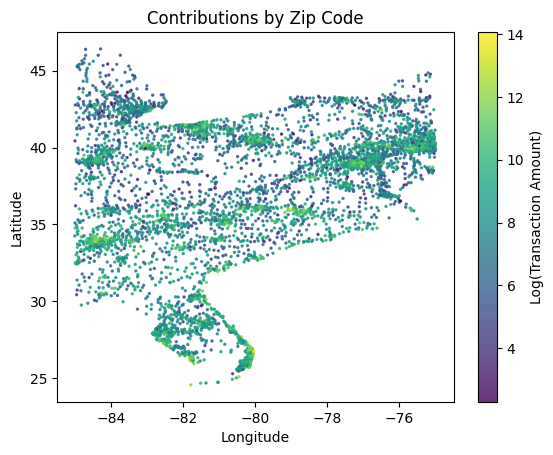

In [8]:
# plot lat and lng of contributions, colored by log(transaction amount)
plt.scatter(obs_filtered['lon'], obs_filtered['lat'], c=obs_filtered['log_contrib_2022'], 
            cmap='viridis', alpha=0.8, s= 2)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Contributions by Zip Code')
plt.colorbar(label='Log(Transaction Amount)')
plt.show()

In [11]:
obs_filtered.columns

Index(['ZIP_CODE', 'STATE', 'lat', 'lon', 'population', 'median_income',
       'prop_college_degree_or_higher_18plus',
       'prop_high_school_or_higher_18plus', 'election_diff',
       'TRANSACTION_AMT_2020', 'TRANSACTION_AMT_2022', 'log_contrib_2020',
       'log_contrib_2022', 'log_income', 'log_population'],
      dtype='str')

In [ ]:
obs_chosen = obs_filtered[['ZIP_CODE', 'STATE', 'lat', 'lon',
                           'prop_high_school_or_higher_18plus',
                           'prop_college_degree_or_higher_18plus', 
                          'election_diff', 'log_contrib_2020', 'log_contrib_2022',
                          'log_income', 'log_population']]
# save csv
obs_chosen.to_csv("../data/obs_chosen.csv")

In [ ]:
covariates = ['prop_college_degree_or_higher_18plus', 
                     'election_diff', 'log_contrib_2020', 'log_income', 'log_population']

X = obs_filtered[covariates].astype(float)
X = (X - X.mean()) / X.std(ddof=0)
X = sm.add_constant(X)

ols_log_contrib_2022 = sm.OLS(obs_filtered["log_contrib_2022"], X).fit()
obs_filtered["log_contrib_2022_ols_fitted"] = ols_log_contrib_2022.fittedvalues
obs_filtered["log_contrib_2022_resid"] = ols_log_contrib_2022.resid
ols_log_contrib_2022.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       log_contrib_2022   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                     2025.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        18:14:33   Log-Likelihood:                -7734.8
No. Observations:                5145   AIC:                         1.548e+04
Df Residuals:                    5139   BIC:                         1.552e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    8.1947      0.015    539.889      0.000       8.165       8.224
prop_college_degree_or_higher_18plus     0.5482      0.026     20.841      0.000       0.497       0.600
election_diff                            0.3632      0.016     23.253      0.000       0.333       0.394
log_contrib_2020                         0.8810      0.024     36.314      0.000       0.833       0.929
log_income                              -0.1685      0.022     -7.695      0.000      -0.211      -0.126
log_population                           0.4634      0.019     24.078      0.000       0.426       0.501
==============================================================================
Omnibus:                      306.205   Durbin-Watson:                   1.611
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              548.320
Skew:                          -0.451   Prob(JB):                    8.59e-120
Kurtosis:                       4.320   Cond. No.                         3.47
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
np.cov(obs_filtered["log_income"], obs_filtered["prop_college_degree_or_higher_18plus"])

array([[0.13014868, 0.04103065],
       [0.04103065, 0.02533901]])

In [11]:
# sample split into 80% train, 20% test
train = obs_filtered.sample(frac=0.8, random_state=305)
test = obs_filtered.drop(train.index)

In [12]:
gdf = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train["lon"], train["lat"]),
    crs="EPSG:4326"
)

# use a US projection (meters)
gdf = gdf.to_crs("EPSG:5070")  # NAD83 / Conus Albers

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
values = gdf["log_contrib_2022"].values

In [13]:
maxlag = 500_000   # 500 km
n_lags = 30

bin_edges = np.linspace(0, maxlag, n_lags + 1)

bin_center, gamma, counts = gs.vario_estimate(
    (coords[:,0], coords[:,1]),
    values,
    bin_edges=bin_edges,
    return_counts=True
)

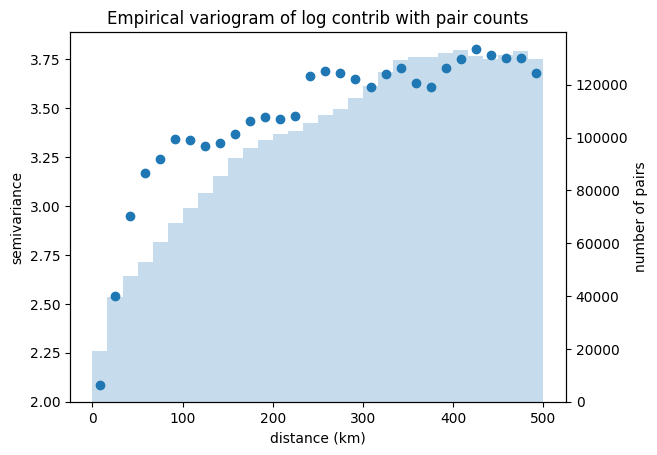

In [14]:
fig, ax1 = plt.subplots()

ax1.scatter(bin_center / 1000, gamma, label="empirical")
ax1.set_xlabel("distance (km)")
ax1.set_ylabel("semivariance")

ax2 = ax1.twinx()
ax2.bar(bin_center / 1000, counts, alpha=0.25, width=(maxlag / n_lags) / 1000)
ax2.set_ylabel("number of pairs")

plt.title("Empirical variogram of log contrib with pair counts")
plt.show()

In [ ]:
# avg number of neighbors within 200 km

In [15]:
model_resid = gs.Spherical(dim=2)
model_resid.fit_variogram(bin_center, gamma)

print("range:", model_resid.len_scale)
print("sill:", model_resid.var)
print("nugget:", model_resid.nugget)

range: 186995.9099878911
sill: 1.311696914943724
nugget: 2.325026987153285


In [16]:
gdf = gpd.GeoDataFrame(
    train,
    geometry=gpd.points_from_xy(train["lon"], train["lat"]),
    crs="EPSG:4326"
)

# use a US projection (meters)
gdf = gdf.to_crs("EPSG:5070")  # NAD83 / Conus Albers

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
values = gdf["log_contrib_2022_resid"].values

In [17]:
maxlag = 500_000   # 500 km
n_lags = 30

bin_edges = np.linspace(0, maxlag, n_lags + 1)

bin_center, gamma, counts = gs.vario_estimate(
    (coords[:,0], coords[:,1]),
    values,
    bin_edges=bin_edges,
    return_counts=True
)

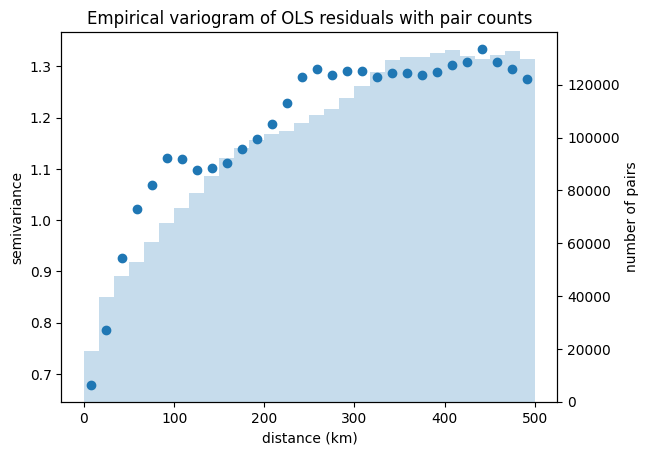

In [18]:
fig, ax1 = plt.subplots()

ax1.scatter(bin_center / 1000, gamma, label="empirical")
ax1.set_xlabel("distance (km)")
ax1.set_ylabel("semivariance")

ax2 = ax1.twinx()
ax2.bar(bin_center / 1000, counts, alpha=0.25, width=(maxlag / n_lags) / 1000)
ax2.set_ylabel("number of pairs")

plt.title("Empirical variogram of OLS residuals with pair counts")
plt.show()

# Bayesian model

In [19]:
RUN_BAYESIAN_SPATIAL = True
BAYESIAN_SAMPLE_N = 2000
BAYESIAN_TRACE_PATH = pathlib.Path("trace_log_contrib_2022.pkl")

In [20]:
def prepare_spatial_log_contrib_2022_data(
    df,
    covariates=('prop_college_degree_or_higher_18plus', 
                     'election_diff', 'log_contrib_2020', 'log_income', 'log_population'),
    sample_n=None,
    random_state=305,
):
    cols = ["log_contrib_2022", "lat", "lon", *covariates]
    sample = df.dropna(subset=cols).copy().reset_index(drop=True)

    if sample_n is not None and sample_n < len(sample):
        sample = sample.sample(n=sample_n, random_state=random_state).reset_index(drop=True)

    gdf = gpd.GeoDataFrame(
        sample,
        geometry=gpd.points_from_xy(sample["lon"], sample["lat"]),
        crs="EPSG:4326",
    ).to_crs("EPSG:5070")
    coords_km = np.column_stack([gdf.geometry.x, gdf.geometry.y]) / 1000

    X_raw = sample[list(covariates)].astype(float)
    covariate_means = X_raw.mean()
    covariate_sds = X_raw.std(ddof=0).replace(0, 1)

    X_scaled = (X_raw - covariate_means) / covariate_sds
    X = np.column_stack([np.ones(len(sample)), X_scaled.values])
    y = sample["log_contrib_2022"].values.astype(float)

    return {
        "sample": sample,
        "coords_km": coords_km,
        "X": X,
        "y": y,
        "covariates": list(covariates),
        "covariate_means": covariate_means,
        "covariate_sds": covariate_sds,
    }

In [21]:
def fit_bayesian_spatial_log_contrib_2022_model(
    df,
    covariates=('prop_college_degree_or_higher_18plus', 
                     'election_diff', 'log_contrib_2020', 'log_income', 'log_population'),
    sample_n=None,
    draws=1000,
    tune=1000,
    chains=4,
    cores=1,
    target_accept=0.9,
    beta_sigma=10.0,
    nugget_ratio_bounds=(1.0, 100.0),
    inv_phi_bounds=(1.0, 2000.0),  # kilometers, after EPSG:5070 projection
    n_prior_samples=100,
    jitter=1e-6,
    **pm_kwargs,
):
    data = prepare_spatial_log_contrib_2022_data(
        df,
        covariates=covariates,
        sample_n=sample_n,
    )

    X = data["X"]
    y = data["y"]
    coords_km = data["coords_km"]
    D = cdist(coords_km, coords_km)
    n = len(y)

    with pm.Model() as model:
        log_sigma2 = pm.Normal("log_sigma2", mu=0, sigma=10)
        sigma2 = pm.Deterministic("sigma2", pm.math.exp(log_sigma2))
        nugget_ratio = pm.Uniform(
            "nugget_ratio",
            lower=nugget_ratio_bounds[0],
            upper=nugget_ratio_bounds[1],
        )
        inv_phi = pm.Uniform(
            "inv_phi",
            lower=inv_phi_bounds[0],
            upper=inv_phi_bounds[1],
        )
        phi = pm.Deterministic("phi", 1.0 / inv_phi)
        beta = pm.Normal("beta", mu=0, sigma=beta_sigma, shape=X.shape[1])

        H = pm.math.exp(-(phi ** 2) * D ** 2)
        Sigma = sigma2 * H + nugget_ratio * sigma2 * pt.eye(n) + jitter * pt.eye(n)
        mu = pm.math.dot(X, beta)
        pm.MvNormal("y_obs", mu=mu, cov=Sigma, observed=y)

        prior = pm.sample_prior_predictive(samples=n_prior_samples)
        trace = pm.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=target_accept,
            idata_kwargs={"log_likelihood": True},
            return_inferencedata=True,
            **pm_kwargs,
        )
        pm.sample_posterior_predictive(trace, extend_inferencedata=True)

    trace.extend(prior)
    return trace, data


In [ ]:
trace_delta_census = None
bayes_train_data = None

if RUN_BAYESIAN_SPATIAL:
    trace_delta_census, bayes_train_data = fit_bayesian_spatial_log_contrib_2022_model(
        train,
        sample_n=BAYESIAN_SAMPLE_N,
        covariates = ('prop_college_degree_or_higher_18plus', 
                     'election_diff', 'log_contrib_2020', 'log_income', 'log_population'),
        draws=500,
        tune=500,
        chains=4,
        cores=1,
        target_accept=0.9,
        nugget_ratio_bounds=(1.0, 100.0),
        inv_phi_bounds=(1.0, 2000.0),
        beta_sigma=5.0,
        n_prior_samples=100,
    )
    with open(BAYESIAN_TRACE_PATH, "wb") as f:
        pickle.dump({"trace": trace_delta_census, "data": bayes_train_data}, f)
elif BAYESIAN_TRACE_PATH.exists():
    with open(BAYESIAN_TRACE_PATH, "rb") as f:
        saved = pickle.load(f)
    trace_delta_census = saved["trace"]
    bayes_train_data = saved["data"]


Sampling: [beta, inv_phi, log_sigma2, nugget_ratio, y_obs]
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [log_sigma2, nugget_ratio, inv_phi, beta]


Output()

Divergences:          0
Mean acceptance rate: 0.918
Mean step size:       0.0944
Max tree depth:       8


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],-3.3719,0.4322,-4.1396,-2.6464,0.0146,0.0337,1633.0367,1016.3672,1.0017
beta[1],0.2813,0.1553,-0.0026,0.5732,0.0031,0.0027,2529.2246,2405.9573,1.0010
beta[2],0.1487,0.1618,-0.1522,0.4543,0.0036,0.0027,2045.0509,2563.0054,1.0005
sigma2,1.0024,0.7541,0.1166,2.1361,0.0266,0.0836,858.5148,797.6053,1.0024
nugget_ratio,15.9173,13.2948,1.1271,39.1259,0.5423,0.8797,845.0027,756.9594,1.0024
inv_phi,393.4755,372.0395,82.5399,1272.1828,17.5255,21.3142,770.9780,753.3046,1.0010


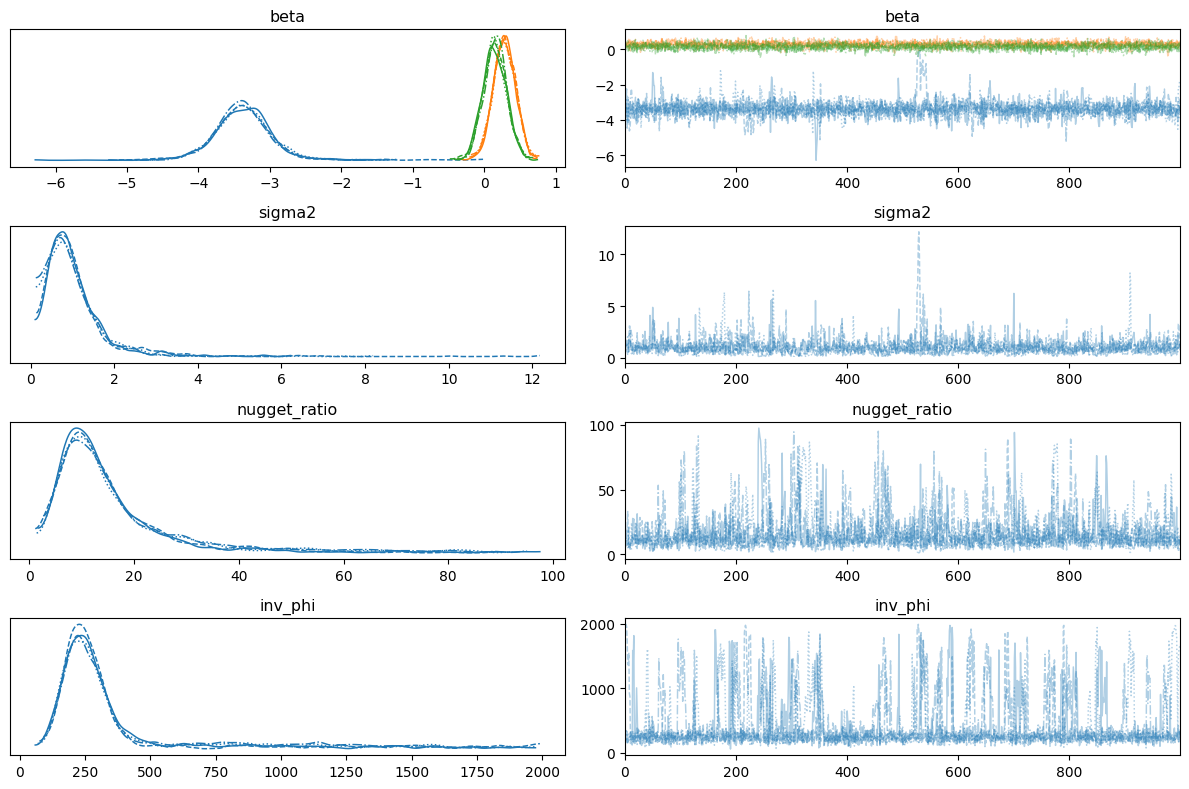

In [32]:
if trace_delta_census is not None:
    diag_vars = ["beta", "sigma2", "nugget_ratio", "inv_phi"]

    n_div = int(trace_delta_census.sample_stats["diverging"].values.sum())
    acc = float(trace_delta_census.sample_stats["acceptance_rate"].values.mean())
    step = float(trace_delta_census.sample_stats["step_size"].values.mean())
    max_td = int(trace_delta_census.sample_stats["tree_depth"].values.max())

    print(f"Divergences:          {n_div}")
    print(f"Mean acceptance rate: {acc:.3f}")
    print(f"Mean step size:       {step:.4f}")
    print(f"Max tree depth:       {max_td}")
    display(az.summary(trace_delta_census, var_names=diag_vars, round_to=4))

    az.plot_trace(trace_delta_census, var_names=diag_vars, compact=True)
    plt.tight_layout()

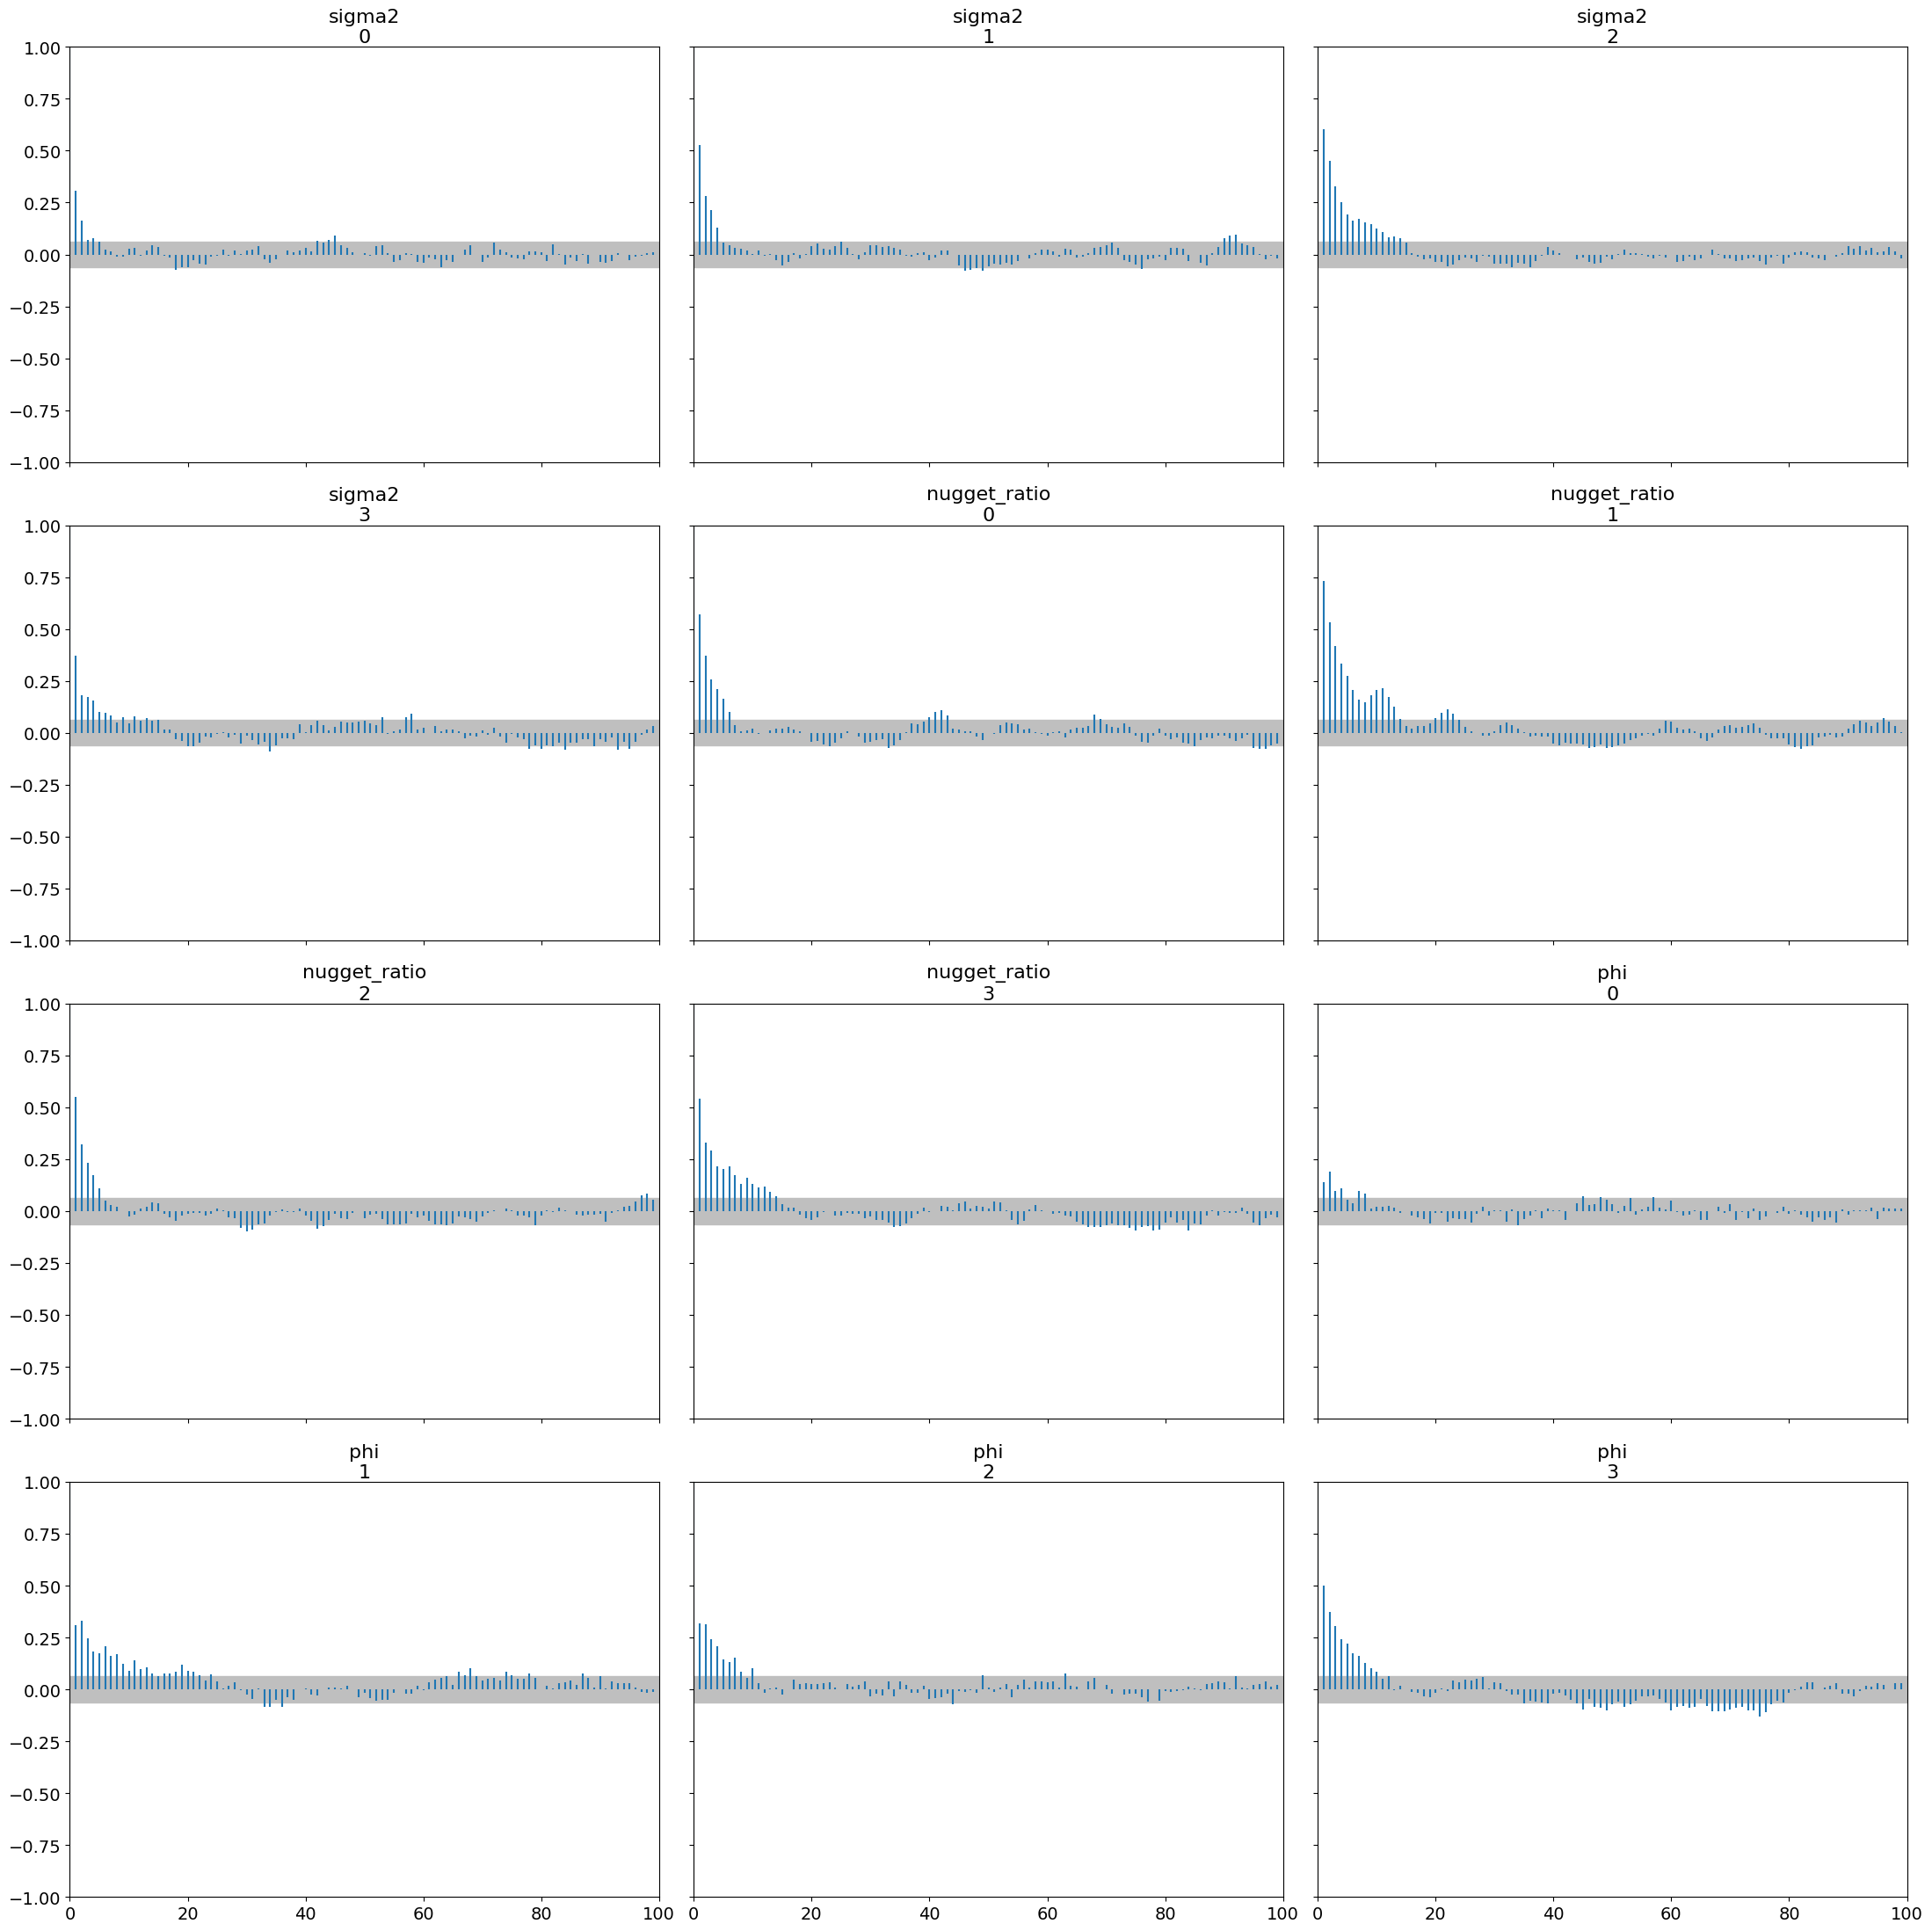

In [37]:
# autocorrelation plots for the main spatial parameters
if trace_delta_census is not None:
    az.plot_autocorr(trace_delta_census, var_names=["sigma2", "nugget_ratio", "phi"])
    plt.tight_layout()

In [33]:
def bayesian_spatial_delta_predict(trace, train_data, test_df, n_posterior_samples=200):
    test_data = prepare_spatial_delta_data(
        test_df,
        covariates=train_data["covariates"],
        covariate_means=train_data["covariate_means"],
        covariate_sds=train_data["covariate_sds"],
    )

    X_train = train_data["X"]
    X_test = test_data["X"]
    y_train = train_data["y"]
    y_test = test_data["y"]
    coords_train = train_data["coords_km"]
    coords_test = test_data["coords_km"]

    D_tt = cdist(coords_train, coords_train)
    D_st = cdist(coords_test, coords_train)

    post = trace.posterior
    beta = post["beta"].values.reshape(-1, post["beta"].shape[-1])
    sigma2 = post["sigma2"].values.reshape(-1)
    phi = post["phi"].values.reshape(-1)
    nugget = post["nugget_ratio"].values.reshape(-1)

    idx = np.linspace(0, len(sigma2) - 1, min(n_posterior_samples, len(sigma2)), dtype=int)
    preds = np.zeros((len(idx), len(test_data["sample"])))

    for k, s in enumerate(idx):
        H_tt = np.exp(-(phi[s] ** 2) * D_tt ** 2)
        H_st = np.exp(-(phi[s] ** 2) * D_st ** 2)
        Sigma_tt = sigma2[s] * H_tt + nugget[s] * sigma2[s] * np.eye(len(y_train))
        Sigma_st = sigma2[s] * H_st
        mu_train = X_train @ beta[s]
        mu_test = X_test @ beta[s]
        preds[k] = mu_test + Sigma_st @ np.linalg.solve(Sigma_tt, y_train - mu_train)

    return preds.mean(axis=0), y_test, test_data

In [39]:
if trace_delta_census is not None and bayes_train_data is not None:
    bayes_pred, bayes_y_test, bayes_test_data = bayesian_spatial_delta_predict(
        trace_delta_census,
        bayes_train_data,
        test,
        n_posterior_samples=200,
    )

    bayes_errors = bayes_y_test - bayes_pred
    ols_test_errors = bayes_y_test - bayes_test_data["sample"]["delta_log_ols_fitted"].values
    null_test_errors = bayes_y_test - bayes_train_data["y"].mean()

    bayes_comparison = pd.DataFrame({
        "model": ["Train mean", "OLS census", "Bayesian spatial census"],
        "RMSE": [
            np.sqrt(np.mean(null_test_errors ** 2)),
            np.sqrt(np.mean(ols_test_errors ** 2)),
            np.sqrt(np.mean(bayes_errors ** 2)),
        ],
    })
    display(bayes_comparison)

,model,RMSE
0,Train mean,3.304215
1,OLS census,3.273140
2,Bayesian spatial census,3.244915


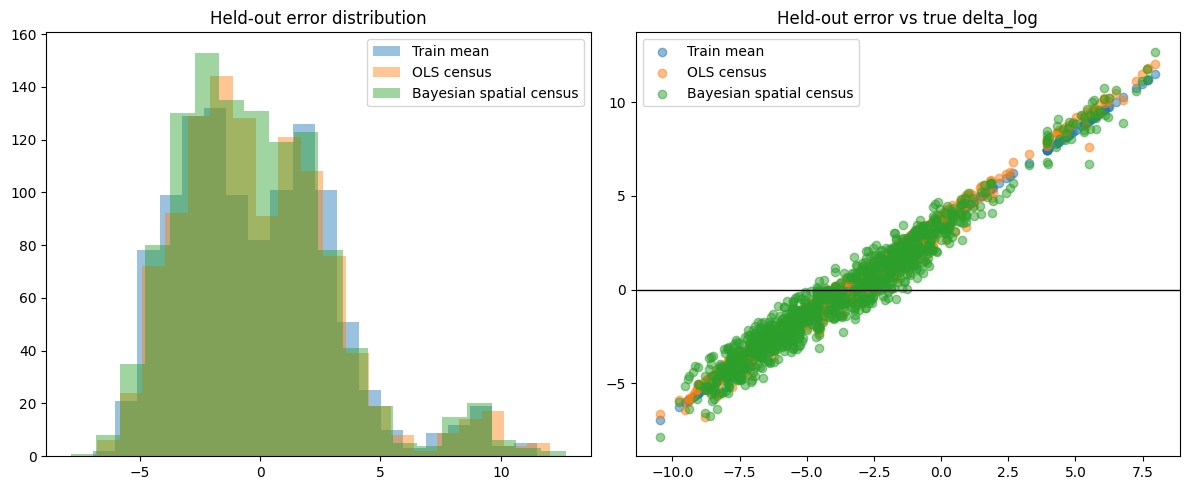

In [35]:
if trace_delta_census is not None and bayes_train_data is not None:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(null_test_errors, bins=20, alpha=0.45, label="Train mean")
    plt.hist(ols_test_errors, bins=20, alpha=0.45, label="OLS census")
    plt.hist(bayes_errors, bins=20, alpha=0.45, label="Bayesian spatial census")
    plt.legend()
    plt.title("Held-out error distribution")

    plt.subplot(1, 2, 2)
    plt.scatter(bayes_y_test, null_test_errors, alpha=0.5, label="Train mean")
    plt.scatter(bayes_y_test, ols_test_errors, alpha=0.5, label="OLS census")
    plt.scatter(bayes_y_test, bayes_errors, alpha=0.5, label="Bayesian spatial census")
    plt.axhline(0, color="black", linewidth=1)
    plt.legend()
    plt.title("Held-out error vs true delta_log")

    plt.tight_layout()